#**Customer Churn Prediction (Classification)**

#**Problem Statement**
Customer churn is a major concern for businesses, especially in industries like telecom,
banking, and SaaS. Losing customers leads to revenue loss and increased acquisition costs.
In this project, the goal is to build a Machine Learning classification model that predicts
whether a customer will leave the company (Churn: Yes/No) based on features.

In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('customer_churn_dataset.csv')

In [3]:
data

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes
...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,36,69.51,2502.36,Two year,Cash,DSL,No,Yes,0,Yes
19996,19997,10,59.88,598.80,Month-to-month,UPI,Fiber,Yes,No,1,No
19997,19998,6,42.96,257.76,Month-to-month,Credit,Fiber,No,No,2,No
19998,19999,7,102.85,719.95,Month-to-month,Debit,DSL,Yes,No,2,No


In [4]:
data.head()

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes


In [5]:
data.tail()

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
19995,19996,36,69.51,2502.36,Two year,Cash,DSL,No,Yes,0,Yes
19996,19997,10,59.88,598.80,Month-to-month,UPI,Fiber,Yes,No,1,No
19997,19998,6,42.96,257.76,Month-to-month,Credit,Fiber,No,No,2,No
19998,19999,7,102.85,719.95,Month-to-month,Debit,DSL,Yes,No,2,No
19999,20000,31,44.84,1390.04,Two year,Credit,Fiber,Yes,No,1,Yes


In [6]:
data.shape

(20000, 11)

In [7]:
data.columns

Index(['customer_id', 'tenure', 'monthly_charges', 'total_charges', 'contract',
       'payment_method', 'internet_service', 'tech_support', 'online_security',
       'support_calls', 'churn'],
      dtype='object')

In [8]:
data.describe()

,customer_id,tenure,monthly_charges,total_charges,support_calls
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,10000.500000,36.467450,70.010531,2543.979209,1.51255
std,5773.647028,20.773984,28.890239,1882.949804,1.23524
min,1.000000,1.000000,20.000000,20.230000,0.00000
25%,5000.750000,18.000000,45.210000,1045.837500,1.00000
50%,10000.500000,36.000000,70.090000,2096.495000,1.00000
75%,15000.250000,54.000000,95.072500,3690.337500,2.00000
max,20000.000000,72.000000,120.000000,8629.920000,8.00000


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       20000 non-null  int64  
 1   tenure            20000 non-null  int64  
 2   monthly_charges   20000 non-null  float64
 3   total_charges     20000 non-null  float64
 4   contract          20000 non-null  object 
 5   payment_method    20000 non-null  object 
 6   internet_service  17987 non-null  object 
 7   tech_support      20000 non-null  object 
 8   online_security   20000 non-null  object 
 9   support_calls     20000 non-null  int64  
 10  churn             20000 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 1.7+ MB


In [10]:
data.dtypes

,0
customer_id,int64
tenure,int64
monthly_charges,float64
total_charges,float64
contract,object
payment_method,object
internet_service,object
tech_support,object
online_security,object
support_calls,int64


**Handling missing values**

In [11]:
data.isnull().sum()

,0
customer_id,0
tenure,0
monthly_charges,0
total_charges,0
contract,0
payment_method,0
internet_service,2013
tech_support,0
online_security,0
support_calls,0


**internet_service**

In [12]:
data.loc[:,'internet_service'].dtypes

dtype('O')

In [13]:
data.loc[:,'internet_service'].mode()[0]

'Fiber'

In [14]:
data.loc[:,'internet_service']=data.loc[:,'internet_service'].fillna(data.loc[:,'internet_service'].mode()[0])


In [15]:
data.isnull().sum()

,0
customer_id,0
tenure,0
monthly_charges,0
total_charges,0
contract,0
payment_method,0
internet_service,0
tech_support,0
online_security,0
support_calls,0


In [16]:
#Duplicates
data.duplicated().sum()

np.int64(0)

**No Duplicates**

In [17]:
num_cols = data.select_dtypes(include=['int64','float64'])
num_cols

,customer_id,tenure,monthly_charges,total_charges,support_calls
0,1,52,54.20,2818.40,1
1,2,15,35.28,529.20,2
2,3,72,78.24,5633.28,0
3,4,61,80.24,4894.64,0
4,5,21,39.38,826.98,4
...,...,...,...,...,...
19995,19996,36,69.51,2502.36,0
19996,19997,10,59.88,598.80,1
19997,19998,6,42.96,257.76,2
19998,19999,7,102.85,719.95,2


In [18]:
cat_cols=data.select_dtypes(include=['object'])
cat_cols

,contract,payment_method,internet_service,tech_support,online_security,churn
0,Month-to-month,Credit,DSL,No,Yes,No
1,Month-to-month,Debit,DSL,No,No,No
2,Month-to-month,Debit,DSL,No,No,No
3,One year,Cash,Fiber,Yes,Yes,No
4,Month-to-month,UPI,Fiber,No,No,Yes
...,...,...,...,...,...,...
19995,Two year,Cash,DSL,No,Yes,Yes
19996,Month-to-month,UPI,Fiber,Yes,No,No
19997,Month-to-month,Credit,Fiber,No,No,No
19998,Month-to-month,Debit,DSL,Yes,No,No


**univariate analysis**

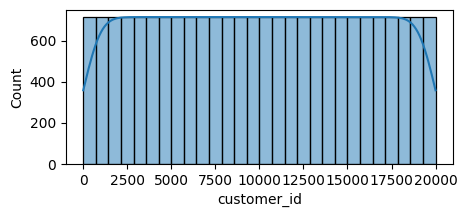

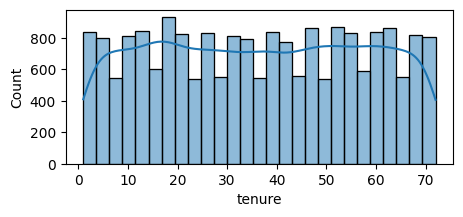

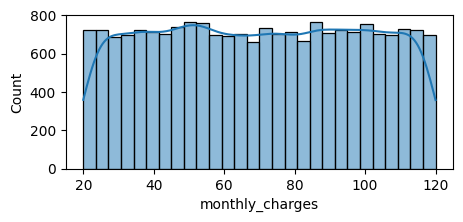

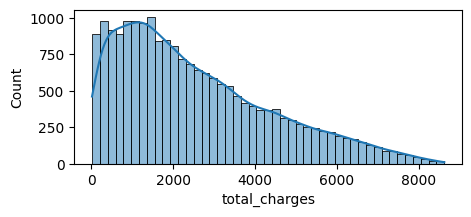

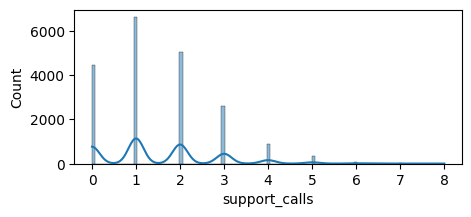

In [19]:
for x in num_cols:
  plt.figure(figsize=(5,2))
  sns.histplot(data[x],kde=True)
  plt.show()

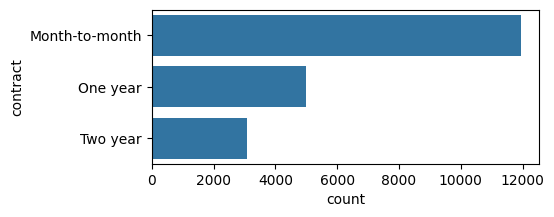

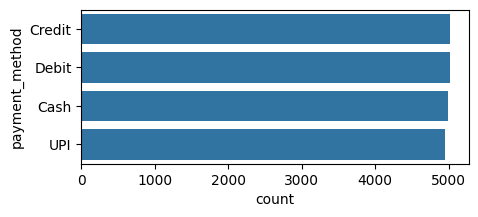

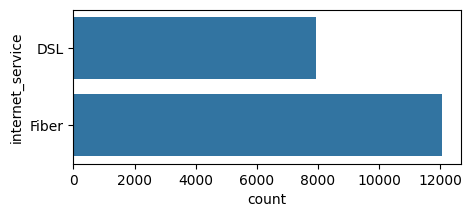

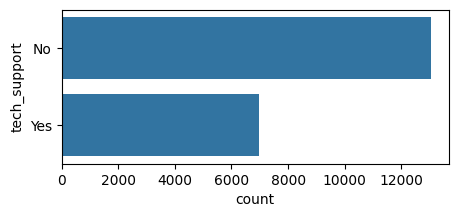

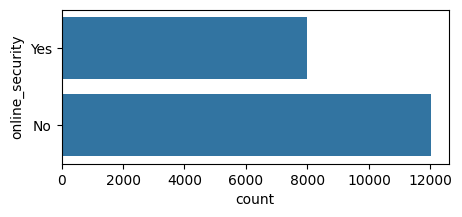

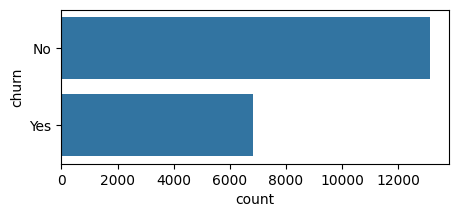

In [20]:
for x in cat_cols:
  plt.figure(figsize=(5,2))
  sns.countplot(data[x])
  plt.show()

**Bivariate analysis**

**Churn vs numerical features**

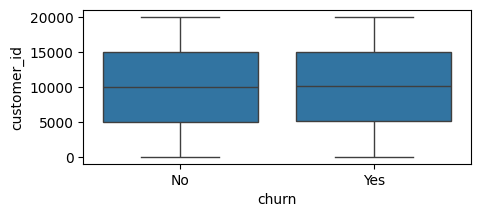

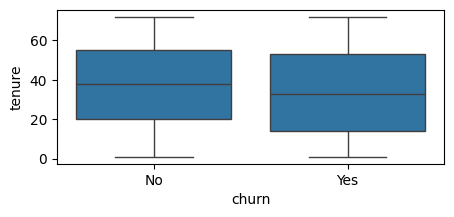

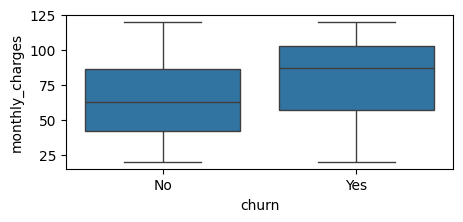

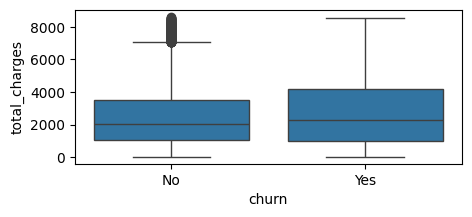

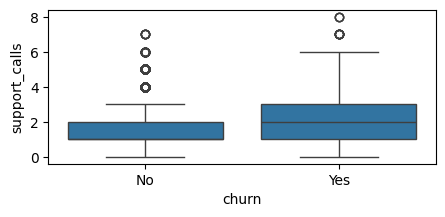

In [21]:
for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x='churn', y=col, data=data)
    plt.show()

**Churn vs categorical features**

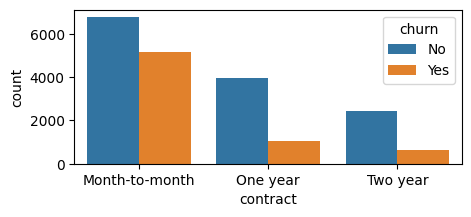

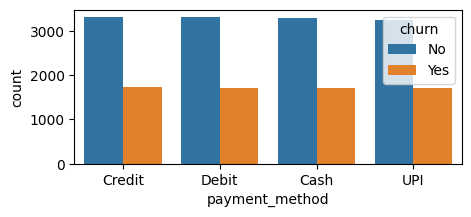

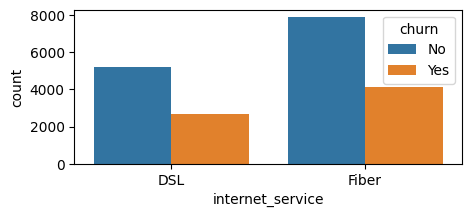

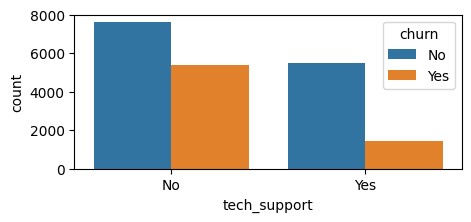

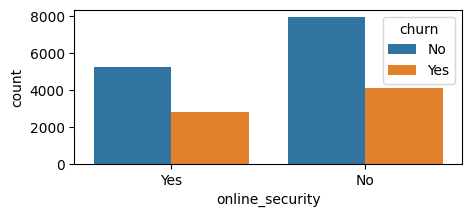

In [22]:
for col in cat_cols:
    if col != 'churn':
        plt.figure(figsize=(5,2))
        sns.countplot(x=col, hue='churn', data=data)
        plt.show()

**Heatmap**

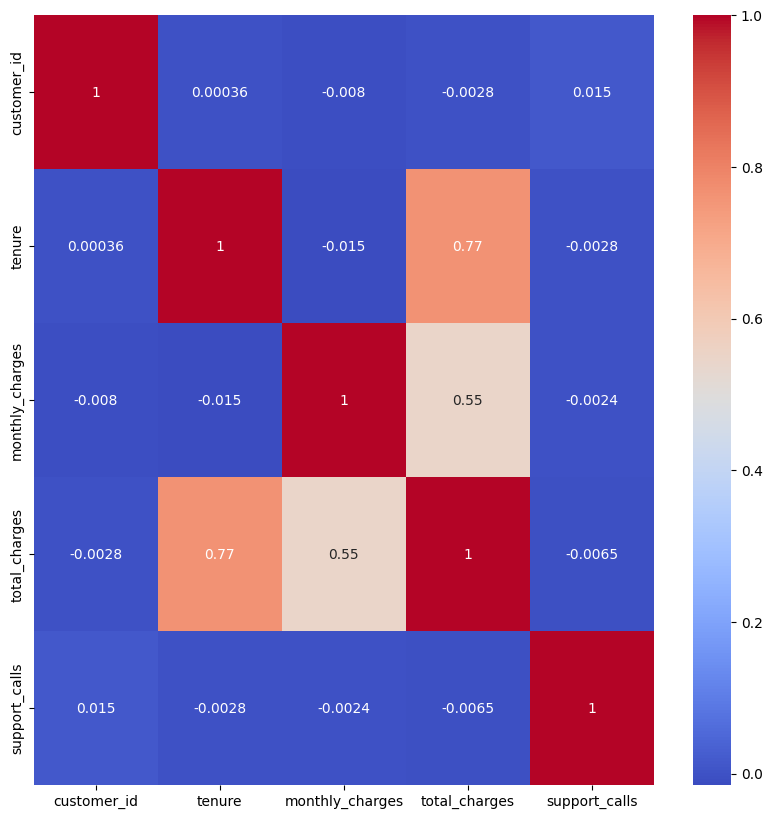

In [23]:
corr_matrix = num_cols.corr()
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

**Detecting and handling outliers**

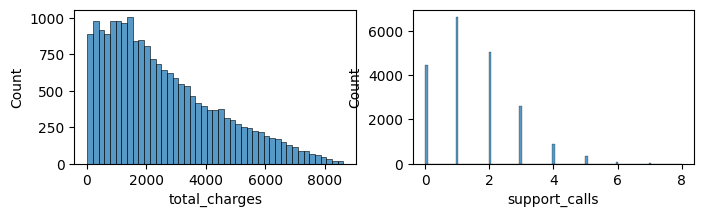

In [24]:
#total_charges and support_calls
fig,ax=plt.subplots(1,2,figsize=(8,2))
sns.histplot(data,x='total_charges',ax=ax[0])
sns.histplot(data,x='support_calls',ax=ax[1])
plt.show()

- find skew
- skew=[-0.5,0.5]-->normal
- skew>0.5-->rigth skew
- skew<-0.5 --->left skew

**total_charges**

In [25]:
data.loc[:,'total_charges'].skew()

np.float64(0.8298767306342206)

In [26]:
Q1 = data['total_charges'].quantile(0.25)
Q3 = data['total_charges'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [27]:
data[(data.loc[:,'total_charges']>upper)|(data.loc[:,'total_charges']<lower)]

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
122,123,71,110.50,7845.50,One year,UPI,Fiber,Yes,Yes,0,No
243,244,67,119.11,7980.37,Month-to-month,UPI,Fiber,Yes,Yes,0,Yes
741,742,70,110.04,7702.80,Month-to-month,UPI,Fiber,No,No,2,Yes
802,803,69,118.16,8153.04,Month-to-month,Credit,Fiber,No,No,1,Yes
811,812,64,119.94,7676.16,One year,Credit,DSL,No,No,2,No
...,...,...,...,...,...,...,...,...,...,...,...
18980,18981,70,117.21,8204.70,Two year,UPI,Fiber,Yes,No,0,No
19046,19047,69,118.07,8146.83,Two year,Credit,DSL,Yes,No,2,No
19543,19544,69,111.73,7709.37,One year,Credit,DSL,No,No,1,Yes
19598,19599,69,115.40,7962.60,One year,UPI,DSL,No,No,3,Yes


In [28]:
len(data[(data.loc[:,'total_charges']>upper)|(data.loc[:,'total_charges']<lower)])/len(data)*100

0.885

In [29]:
# since % of outliers is less than 5% lets replace with median(distribution is skewed)
data.loc[(data.loc[:,'total_charges']>upper)|
 (data.loc[:,'total_charges']<lower),'total_charges']=data.loc[:,'total_charges'].median()

In [30]:
data[(data.loc[:,'total_charges']>upper)|(data.loc[:,'total_charges']<lower)]

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn


In [31]:
len(data[(data.loc[:,'total_charges']>upper)|(data.loc[:,'total_charges']<lower)])/len(data)*100

0.0

**support_calls**

In [32]:
Q1 = data['support_calls'].quantile(0.25)
Q3 = data['support_calls'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [33]:
data[(data.loc[:,'support_calls']>upper)|(data.loc[:,'support_calls']<lower)]

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes
32,33,51,90.90,4635.90,Month-to-month,Credit,Fiber,No,No,6,Yes
37,38,4,89.68,358.72,Month-to-month,Cash,Fiber,No,No,4,Yes
59,60,44,76.64,3372.16,One year,Debit,DSL,Yes,No,4,No
68,69,53,81.49,4318.97,Month-to-month,UPI,Fiber,Yes,No,4,Yes
...,...,...,...,...,...,...,...,...,...,...,...
19944,19945,27,69.31,1871.37,Two year,UPI,Fiber,No,Yes,4,No
19949,19950,25,80.08,2002.00,Month-to-month,Debit,DSL,No,No,4,Yes
19968,19969,65,69.97,4548.05,Month-to-month,Credit,DSL,No,No,4,Yes
19970,19971,21,44.13,926.73,One year,Debit,DSL,No,Yes,4,No


In [34]:
len(data[(data.loc[:,'support_calls']>upper)|(data.loc[:,'support_calls']<lower)])/len(data)*100

6.625

**Encoding**

In [35]:
data

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes
...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,36,69.51,2502.36,Two year,Cash,DSL,No,Yes,0,Yes
19996,19997,10,59.88,598.80,Month-to-month,UPI,Fiber,Yes,No,1,No
19997,19998,6,42.96,257.76,Month-to-month,Credit,Fiber,No,No,2,No
19998,19999,7,102.85,719.95,Month-to-month,Debit,DSL,Yes,No,2,No


In [36]:
#tech_support->label encoding
#online_security->label encoding
#churn->label encoding
#contract->target encoding
#payment_method-> target encoding
#internet_service->target encoding

In [37]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['tech_support'] = le.fit_transform(data['tech_support'])
data['online_security'] = le.fit_transform(data['online_security'])
data['churn'] = le.fit_transform(data['churn'])

In [38]:
data.loc[:,'contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [39]:
data.loc[:,'contract']=data.loc[:,'contract'].map({'Month-to-month':1,'One year':2,'Two year':3})

In [40]:
data.loc[:,'payment_method'].unique()

array(['Credit', 'Debit', 'Cash', 'UPI'], dtype=object)

In [41]:
data.loc[:, 'payment_method'] = data.loc[:, 'payment_method'].map({
    'Credit': 0,
    'Debit': 1,
    'Cash': 2,
    'UPI': 3
})

In [42]:
data.loc[:,'internet_service'].unique()

array(['DSL', 'Fiber'], dtype=object)

In [43]:
data.loc[:,'internet_service']=data.loc[:,'internet_service'].map({'DSL':1,'Fiber':0})

In [44]:
data

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,1,0,1,0,1,1,0
1,2,15,35.28,529.20,1,1,1,0,0,2,0
2,3,72,78.24,5633.28,1,1,1,0,0,0,0
3,4,61,80.24,4894.64,2,2,0,1,1,0,0
4,5,21,39.38,826.98,1,3,0,0,0,4,1
...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,36,69.51,2502.36,3,2,1,0,1,0,1
19996,19997,10,59.88,598.80,1,3,0,1,0,1,0
19997,19998,6,42.96,257.76,1,0,0,0,0,2,0
19998,19999,7,102.85,719.95,1,1,1,1,0,2,0


In [45]:
data['contract'] = data['contract'].astype(int)
data['payment_method'] = data['payment_method'].astype(int)
data['internet_service'] = data['internet_service'].astype(int)

In [46]:
data.dtypes

,0
customer_id,int64
tenure,int64
monthly_charges,float64
total_charges,float64
contract,int64
payment_method,int64
internet_service,int64
tech_support,int64
online_security,int64
support_calls,int64


In [47]:
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

# Separate features & target
x = data.drop('churn', axis=1)
y = data['churn']

In [48]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [49]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

**Balancing data**

In [50]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_sm, y_sm = smote.fit_resample(x_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_sm.value_counts())

Before SMOTE: churn
0    10512
1     5488
Name: count, dtype: int64
After SMOTE: churn
0    10512
1    10512
Name: count, dtype: int64


**Train Classification Models**

**Logistic Regression**

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

In [52]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [53]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]   # for ROC-AUC

In [54]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.78025
Precision: 0.74435318275154
Recall   : 0.5350553505535055
F1 Score : 0.6225848003434951
ROC-AUC  : 0.7879767576503742

Confusion Matrix:
 [[2396  249]
 [ 630  725]]


**K-Nearest Neighbors (KNN)**

In [55]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)
y_prob = knn.predict_proba(x_test)[:, 1]

In [56]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.78925
Precision: 0.7406015037593985
Recall   : 0.581549815498155
F1 Score : 0.6515088879702357
ROC-AUC  : 0.7767795534288047

Confusion Matrix:
 [[2369  276]
 [ 567  788]]


**Decision Tree Classifier**

In [57]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

y_pred = dt.predict(x_test)
y_prob = dt.predict_proba(x_test)[:, 1]

In [58]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.73425
Precision: 0.6047345767575323
Recall   : 0.622140221402214
F1 Score : 0.6133139323390324
ROC-AUC  : 0.7069113205309748

Confusion Matrix:
 [[2094  551]
 [ 512  843]]


**Random Forest Classifier**

In [59]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)
y_prob = rf.predict_proba(x_test)[:, 1]

In [60]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.8545
Precision: 0.8595348837209302
Recall   : 0.6819188191881919
F1 Score : 0.7604938271604939
ROC-AUC  : 0.8102852279940569

Confusion Matrix:
 [[2494  151]
 [ 431  924]]


**Support Vector Classifier (SVC)**

In [61]:
from sklearn.svm import SVC
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# model (probability=True needed for ROC-AUC)
svc = SVC(kernel='rbf', probability=True, random_state=42)
svc.fit(x_train, y_train)

# predictions
y_pred = svc.predict(x_test)
y_prob = svc.predict_proba(x_test)[:, 1]

In [62]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.82475
Precision: 0.8371134020618557
Recall   : 0.5992619926199262
F1 Score : 0.698494623655914
ROC-AUC  : 0.8131359733257068

Confusion Matrix:
 [[2487  158]
 [ 543  812]]





**Gradient Boosting Classifier**

In [63]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(x_train, y_train)

y_pred = gb.predict(x_test)
y_prob = gb.predict_proba(x_test)[:, 1]

In [64]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.854
Precision: 0.8592730661696178
Recall   : 0.6804428044280443
F1 Score : 0.7594728171334432
ROC-AUC  : 0.8214518795471508

Confusion Matrix:
 [[2494  151]
 [ 433  922]]


**XGBoost Classifier**

In [65]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:17:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [66]:
y_pred = xgb.predict(x_test)
y_prob = xgb.predict_proba(x_test)[:, 1]

In [67]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.85475
Precision: 0.8616822429906542
Recall   : 0.6804428044280443
F1 Score : 0.7604123711340206
ROC-AUC  : 0.8211266819662525

Confusion Matrix:
 [[2497  148]
 [ 433  922]]


#**Hyperparameter Tuning**

**GridSearchCV**

In [68]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

# GridSearch
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# training
grid.fit(x_train, y_train)


# best model
best_model = grid.best_estimator_

# predictions
y_pred = best_model.predict(x_test)

# accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:17:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Accuracy: 0.85575


**RandomizedSearchCV**

In [69]:
from scipy.stats import randint, uniform
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# parameter distribution
param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3)
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,        # number of random combinations
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# training
random_search.fit(x_train, y_train)

# best parameters
print("Best Parameters:", random_search.best_params_)

# best model
best_model = random_search.best_estimator_

# predictions
y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:, 1]

# evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'colsample_bytree': np.float64(0.8199582915145766), 'learning_rate': np.float64(0.019333132642723086), 'max_depth': 6, 'n_estimators': 114, 'subsample': np.float64(0.8368209952651107)}
Accuracy : 0.855
Precision: 0.8597957288765088
Recall   : 0.6833948339483394
F1 Score : 0.7615131578947368
ROC-AUC  : 0.8196413200426899

Confusion Matrix:
 [[2494  151]
 [ 429  926]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:18:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [70]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# results list
results = []

for name, model in models.items():

    if name in ["Logistic Regression", "KNN", "SVC"]:
        model.fit(x_train_scaled, y_train)
        y_pred = model.predict(x_test_scaled)
        y_prob = model.predict_proba(x_test_scaled)[:, 1]
    else:
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        y_prob = model.predict_proba(x_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_data = pd.DataFrame(results)
results_data = results_data.sort_values(by="ROC-AUC", ascending=False)

print(results_data)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
5    Gradient Boosting   0.85400   0.859273  0.680443  0.759473  0.821452
6              XGBoost   0.85050   0.850788  0.677491  0.754314  0.818322
4                  SVC   0.82475   0.837113  0.599262  0.698495  0.813136
3        Random Forest   0.85450   0.859535  0.681919  0.760494  0.810285
0  Logistic Regression   0.78025   0.744353  0.535055  0.622585  0.787977
1                  KNN   0.78925   0.740602  0.581550  0.651509  0.776780
2        Decision Tree   0.73425   0.604735  0.622140  0.613314  0.706911


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:18:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [71]:
import pickle

pickle.dump(rf, open('churn_model.pkl', 'wb'))

In [72]:
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [73]:
print(x.columns)

Index(['customer_id', 'tenure', 'monthly_charges', 'total_charges', 'contract',
       'payment_method', 'internet_service', 'tech_support', 'online_security',
       'support_calls'],
      dtype='object')
